# RANDOM FOREST CLASSIFIER

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

print("Environment setup and imports completed.")

Environment setup and imports completed.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/ML Assignment"
FINAL_MODEL_DIR = os.path.join(BASE_DIR, "final_dataset")

RF_DIR = os.path.join(BASE_DIR, "random_forest")
os.makedirs(RF_DIR, exist_ok=True)

print("Final Model Directory :", FINAL_MODEL_DIR)
print("Random Forest Directory:", RF_DIR)

Mounted at /content/drive
Final Model Directory : /content/drive/MyDrive/ML Assignment/final_dataset
Random Forest Directory: /content/drive/MyDrive/ML Assignment/random_forest


Load final model-ready data

In [3]:
X_train_final = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_train_tree.csv")
)

X_val_final   = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_validation_tree.csv")
)

X_test_final  = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "X_test_tree.csv")
)

MARKET_COLS = [c for c in X_train_final.columns if c.startswith("market_")]
X_train_final = X_train_final.drop(columns=MARKET_COLS)
X_val_final   = X_val_final.drop(columns=MARKET_COLS)
X_test_final  = X_test_final.drop(columns=MARKET_COLS)
assert not any(c.startswith("market_") for c in X_train_final.columns)
print("Dropped market columns:", MARKET_COLS)

y_train_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_train.csv")
).squeeze("columns")

y_val_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_validation.csv")
).squeeze("columns")

y_test_encoded = pd.read_csv(
    os.path.join(FINAL_MODEL_DIR, "y_test.csv")
).squeeze("columns")

target_encoder = joblib.load(os.path.join(FINAL_MODEL_DIR, "target_encoder.joblib"))

print("Matrix Shapes:")
print(f"  Training   : {X_train_final.shape} | Labels: {y_train_encoded.shape}")
print(f"  Validation : {X_val_final.shape}  | Labels: {y_val_encoded.shape}")
print(f"  Test       : {X_test_final.shape}  | Labels: {y_test_encoded.shape}")

print("\nTarget Class Mapping:")
for idx, label in enumerate(target_encoder.classes_):
    print(f"  {idx} -> {label}")

# Verify data integrity
assert list(X_train_final.columns) == list(X_val_final.columns) == list(X_test_final.columns)
assert len(X_train_final) == len(y_train_encoded)
assert len(X_val_final) == len(y_val_encoded)
assert len(X_test_final) == len(y_test_encoded)
assert X_train_final.select_dtypes(exclude=np.number).shape[1] == 0

for d in (X_train_final, X_val_final, X_test_final):
    assert d.isna().sum().sum() == 0 and np.isfinite(d.to_numpy()).all()
print("Data integrity verified.")

Dropped market columns: ['market_home_probability', 'market_draw_probability', 'market_away_probability', 'market_home_probability_std', 'market_draw_probability_std', 'market_away_probability_std', 'market_missing']
Matrix Shapes:
  Training   : (17294, 86) | Labels: (17294,)
  Validation : (3818, 86)  | Labels: (3818,)
  Test       : (3859, 86)  | Labels: (3859,)

Target Class Mapping:
  0 -> Away Win
  1 -> Draw
  2 -> Home Win
Data integrity verified.


Train only Correlation Filter

In [4]:
CORR_THRESHOLD = 0.90
corr_matrix = X_train_final.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_drop_columns = [c for c in upper.columns if (upper[c] > CORR_THRESHOLD).any()]

X_train_corr = X_train_final.drop(columns=corr_drop_columns)
X_val_corr   = X_val_final.drop(columns=corr_drop_columns)
X_test_corr  = X_test_final.drop(columns=corr_drop_columns)

print("Features before:", X_train_final.shape[1], "| removed:", len(corr_drop_columns),
      "| remaining:", X_train_corr.shape[1])
print("Key features kept:",
      [c for c in ["elo_difference", "goals_for_difference"] if c in X_train_corr.columns])


Features before: 86 | removed: 18 | remaining: 68
Key features kept: ['elo_difference', 'goals_for_difference']


Helper function

In [5]:
def predict_with_draw_threshold(p, threshold=0.30):
    p = np.asarray(p)
    return np.where(p[:, 1] >= threshold, 1, np.where(p[:, 2] >= p[:, 0], 2, 0))

def tune_draw_threshold(y_true, proba):
    grid = np.linspace(0.20, 0.42, 23)
    scores = [f1_score(y_true, predict_with_draw_threshold(proba, t),
                       average="macro", zero_division=0) for t in grid]
    best = grid[int(np.argmax(scores))]
    if best in (grid[0], grid[-1]):
        print("WARNING: threshold is at the edge of the grid, widen the search range.")
    return best

def evaluate(y_true, proba, threshold):
    pred = predict_with_draw_threshold(proba, threshold)
    return pred, {
        "Accuracy":        accuracy_score(y_true, pred),
        "Macro Precision": precision_score(y_true, pred, average="macro", zero_division=0),
        "Macro Recall":    recall_score(y_true, pred, average="macro", zero_division=0),
        "Macro F1":        f1_score(y_true, pred, average="macro", zero_division=0),
        "Weighted F1":     f1_score(y_true, pred, average="weighted", zero_division=0),
        "ROC-AUC":         roc_auc_score(y_true, proba, multi_class="ovr", average="weighted"),
        "Argmax Accuracy": accuracy_score(y_true, proba.argmax(axis=1)),
    }

Random Forest MDI Feature Selection for Baseline (train only, balanced)

In [6]:
RF_MAX_FEATURES = 50

rf_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1),

    threshold="median",
    max_features=RF_MAX_FEATURES
)

rf_selector.fit(X_train_corr, y_train_encoded)

rf_selected_features = X_train_corr.columns[rf_selector.get_support()].tolist()

print(f"MDI selected {len(rf_selected_features)} features.")

# Extract subsets as DataFrames
X_train_rf = X_train_corr[rf_selected_features].copy()
X_val_rf = X_val_corr[rf_selected_features].copy()
X_test_rf = X_test_corr[rf_selected_features].copy()

print("Selected Matrix Shapes:")
print(f"  Training   : {X_train_rf.shape}")
print(f"  Validation : {X_val_rf.shape}")
print(f"  Test       : {X_test_rf.shape}")

MDI selected 34 features.
Selected Matrix Shapes:
  Training   : (17294, 34)
  Validation : (3818, 34)
  Test       : (3859, 34)


Train & Evaluate Baseline Random Forest

In [7]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
).fit(X_train_rf, y_train_encoded)

y_train_proba_base = rf_baseline.predict_proba(X_train_rf)
y_val_proba_base   = rf_baseline.predict_proba(X_val_rf)

base_threshold = tune_draw_threshold(
    y_val_encoded,
    y_val_proba_base
)

y_train_pred_base = predict_with_draw_threshold(
    y_train_proba_base,
    base_threshold
)

y_val_pred_base, base_metrics = evaluate(
    y_val_encoded,
    y_val_proba_base,
    base_threshold
)

print("=" * 60)
print("BASELINE RANDOM FOREST")
print("=" * 60)
print(f"Draw threshold      : {base_threshold:.3f}")
print(f"Train Accuracy      : {accuracy_score(y_train_encoded, y_train_pred_base):.4f}")
print(f"Train Macro F1      : {f1_score(y_train_encoded, y_train_pred_base, average='macro'):.4f}")
print(f"Validation Accuracy : {base_metrics['Accuracy']:.4f}")
print(f"Validation Macro F1 : {base_metrics['Macro F1']:.4f}")
print(f"Validation ROC-AUC  : {base_metrics['ROC-AUC']:.4f}")
print(classification_report(y_val_encoded, y_val_pred_base,
                            target_names=target_encoder.classes_, zero_division=0))


BASELINE RANDOM FOREST
Draw threshold      : 0.360
Train Accuracy      : 0.5759
Train Macro F1      : 0.5728
Validation Accuracy : 0.4636
Validation Macro F1 : 0.4543
Validation ROC-AUC  : 0.6635
              precision    recall  f1-score   support

    Away Win       0.48      0.50      0.49      1131
        Draw       0.29      0.40      0.33       955
    Home Win       0.62      0.48      0.54      1732

    accuracy                           0.46      3818
   macro avg       0.46      0.46      0.45      3818
weighted avg       0.50      0.46      0.47      3818



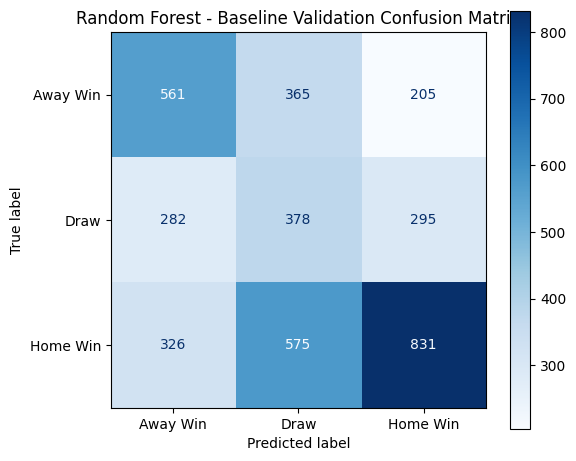

In [8]:
# Plot Baseline Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val_encoded,
    y_val_pred_base,
    display_labels=target_encoder.classes_,
    cmap="Blues",
    ax=ax
)

plt.title("Random Forest - Baseline Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RF_DIR, "baseline_confusion_matrix.png"), dpi=300)
plt.show()

Pipeline + Time-series Tuning

In [9]:
rf_pipeline = Pipeline([
    ("selector", SelectFromModel(
        RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=20,
                               class_weight="balanced_subsample",
                               random_state=42, n_jobs=1),
        threshold="median", max_features=RF_MAX_FEATURES)),
    ("classifier", RandomForestClassifier(
        class_weight="balanced_subsample", random_state=42, n_jobs=1))
])

param_distributions = {
    "classifier__n_estimators":      [200, 300, 400],
    "classifier__max_depth":         [4, 6, 8, 10, 12],
    "classifier__min_samples_split": [20, 40, 80],
    "classifier__min_samples_leaf":  [10, 20, 50, 100],
    "classifier__max_features":      ["sqrt", "log2", 0.3, 0.5],
    "classifier__criterion":         ["gini", "entropy"],
}

cv = TimeSeriesSplit(n_splits=5)

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=25, scoring="f1_macro", cv=cv,
    verbose=1, random_state=42, n_jobs=-1,
    refit=True, return_train_score=True
)
rf_random_search.fit(X_train_corr, y_train_encoded)

print("Best parameters:")
for k, v in rf_random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV Macro F1: {rf_random_search.best_score_:.4f}")

best_rf_pipeline = rf_random_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters:
  classifier__n_estimators: 200
  classifier__min_samples_split: 20
  classifier__min_samples_leaf: 10
  classifier__max_features: log2
  classifier__max_depth: 4
  classifier__criterion: entropy
Best CV Macro F1: 0.4505


Tuned Model Validation (threshold from validation only)

In [10]:
y_val_proba_tuned = best_rf_pipeline.predict_proba(X_val_corr)
best_threshold = tune_draw_threshold(y_val_encoded, y_val_proba_tuned)
print(f"Calibrated Tuned Draw Threshold: {best_threshold:.3f}")

y_val_pred_tuned, val_metrics = evaluate(y_val_encoded, y_val_proba_tuned, best_threshold)

y_train_proba_tuned = best_rf_pipeline.predict_proba(X_train_corr)
y_train_pred_tuned = predict_with_draw_threshold(y_train_proba_tuned, best_threshold)

print("=" * 60)
print("TUNED RANDOM FOREST")
print("=" * 60)
print(f"Train Macro F1      : {f1_score(y_train_encoded, y_train_pred_tuned, average='macro'):.4f}")
print(f"Validation Macro F1 : {val_metrics['Macro F1']:.4f}")
print(f"CV Macro F1         : {rf_random_search.best_score_:.4f}")
print(classification_report(
    y_val_encoded,
    y_val_pred_tuned,
    target_names=target_encoder.classes_,
    zero_division=0)
)

Calibrated Tuned Draw Threshold: 0.360
TUNED RANDOM FOREST
Train Macro F1      : 0.4647
Validation Macro F1 : 0.4538
CV Macro F1         : 0.4505
              precision    recall  f1-score   support

    Away Win       0.49      0.51      0.50      1131
        Draw       0.28      0.37      0.32       955
    Home Win       0.63      0.48      0.55      1732

    accuracy                           0.46      3818
   macro avg       0.46      0.46      0.45      3818
weighted avg       0.50      0.46      0.47      3818



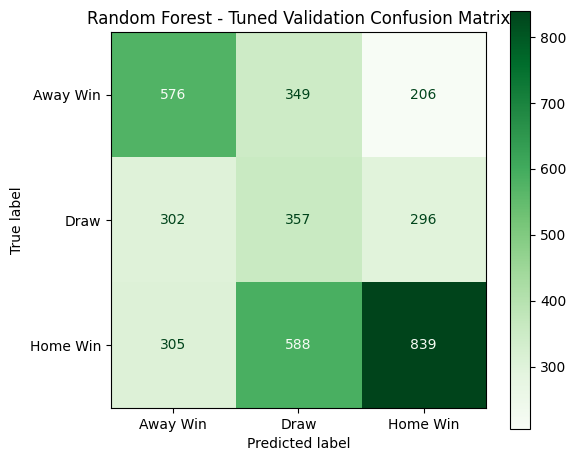

In [11]:
# Plot Tuned Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_val_encoded, y_val_pred_tuned,
    display_labels=target_encoder.classes_, cmap="Greens", ax=ax)
plt.title("Random Forest - Tuned Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RF_DIR, "tuned_validation_confusion_matrix.png"), dpi=300)
plt.show()

Feature Importance of the Final Tuned Model

In [20]:
final_selector   = best_rf_pipeline.named_steps["selector"]
final_classifier = best_rf_pipeline.named_steps["classifier"]
final_rf_features = X_train_corr.columns[final_selector.get_support()].tolist()

feature_importance_df = pd.DataFrame({
    "Feature": final_rf_features,
    "Importance": final_classifier.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)
display(feature_importance_df.head(20))

,Feature,Importance
0,elo_difference,0.160833
1,goals_for_difference,0.146783
2,win_rate_difference,0.133978
3,venue_goals_for_difference,0.079329
4,venue_win_rate_difference,0.051469
5,home_elo_before,0.048180
6,goals_against_difference,0.047904
7,away_loss_rate,0.046388
8,goals_for_last10_difference,0.032171
9,points_last10_difference,0.028060


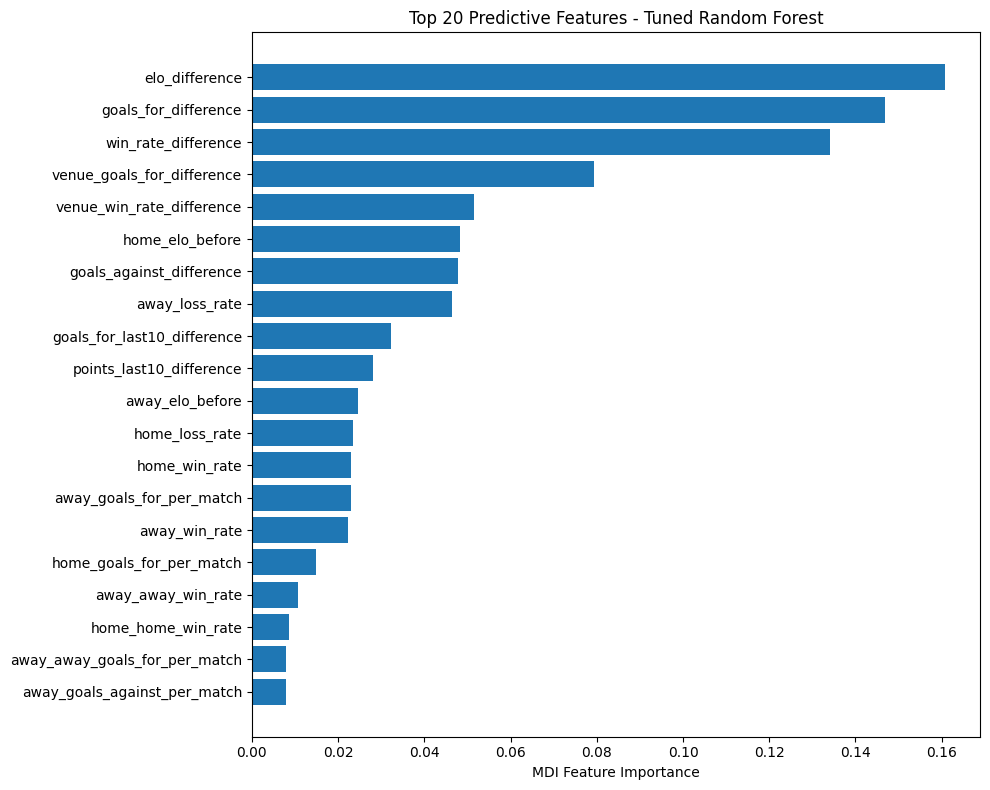

In [14]:
# Plot Top 20 Features
top_20 = feature_importance_df.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(top_20["Feature"], top_20["Importance"], color="#1f77b4")
plt.xlabel("MDI Feature Importance")
plt.title("Top 20 Predictive Features - Tuned Random Forest")
plt.tight_layout()
plt.savefig(os.path.join(RF_DIR, "top_20_feature_importances.png"), dpi=300)
plt.show()

Final Evaluation on the Test Set

In [15]:
y_test_proba = best_rf_pipeline.predict_proba(X_test_corr)
y_test_pred, test_metrics = evaluate(y_test_encoded, y_test_proba, best_threshold)

comparison_df = pd.DataFrame({
    "Baseline Validation": base_metrics,
    "Tuned Validation": val_metrics,
    "Final Test": test_metrics
})
display(comparison_df.round(4))

improvement = (comparison_df["Tuned Validation"] - comparison_df["Baseline Validation"]).rename("Improvement")
display(pd.concat([comparison_df[["Baseline Validation", "Tuned Validation"]], improvement], axis=1).round(4))

print("\nFinal Test Report:")
print(classification_report(y_test_encoded, y_test_pred,
                            target_names=target_encoder.classes_, zero_division=0))

maj = y_train_encoded.value_counts().idxmax()
print("Majority baseline accuracy:",
      round(accuracy_score(y_test_encoded, np.full(len(y_test_encoded), maj)), 4))

dist = pd.DataFrame({
    "Actual": pd.Series(y_test_encoded).value_counts(normalize=True).sort_index(),
    "Predicted": pd.Series(y_test_pred).value_counts(normalize=True).sort_index(),
})
dist.index = target_encoder.classes_
display((dist * 100).round(2))

,Baseline Validation,Tuned Validation,Final Test
Accuracy,0.4636,0.4641,0.4501
Macro Precision,0.4637,0.4628,0.4506
Macro Recall,0.4572,0.4558,0.4411
Macro F1,0.4543,0.4538,0.4405
Weighted F1,0.4738,0.4746,0.4606
ROC-AUC,0.6635,0.6632,0.6503
Argmax Accuracy,0.4699,0.4728,0.4543


,Baseline Validation,Tuned Validation,Improvement
Accuracy,0.4636,0.4641,0.0005
Macro Precision,0.4637,0.4628,-0.0009
Macro Recall,0.4572,0.4558,-0.0014
Macro F1,0.4543,0.4538,-0.0006
Weighted F1,0.4738,0.4746,0.0007
ROC-AUC,0.6635,0.6632,-0.0003
Argmax Accuracy,0.4699,0.4728,0.0029



Final Test Report:
              precision    recall  f1-score   support

    Away Win       0.46      0.46      0.46      1173
        Draw       0.28      0.38      0.32       980
    Home Win       0.62      0.48      0.54      1706

    accuracy                           0.45      3859
   macro avg       0.45      0.44      0.44      3859
weighted avg       0.48      0.45      0.46      3859

Majority baseline accuracy: 0.4421


,Actual,Predicted
Away Win,30.40,30.53
Draw,25.40,34.75
Home Win,44.21,34.72


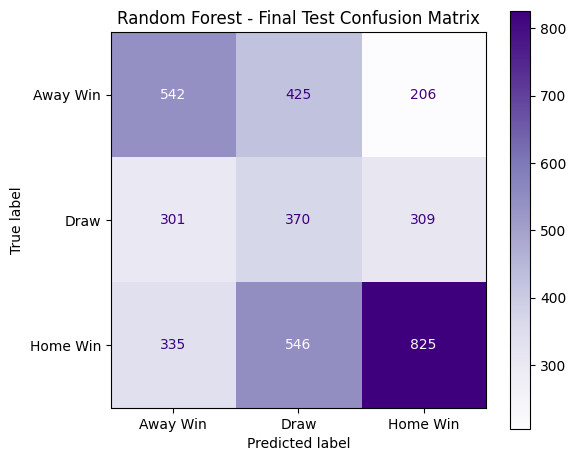

In [16]:
# Final Test Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_test_pred,
    display_labels=target_encoder.classes_,
    cmap="Purples",
    ax=ax
)

plt.title("Random Forest - Final Test Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(RF_DIR, "final_test_confusion_matrix.png"), dpi=300)
plt.show()

In [18]:
# Overall Lifecycle Results Summary Table
final_summary_df = pd.DataFrame({
    "Stage": ["Baseline Validation", "Tuned Validation", "Final Test"],
    "Accuracy": [
        base_metrics["Accuracy"],
        val_metrics["Accuracy"],
        test_metrics["Accuracy"]
    ],
    "Precision": [
        base_metrics["Macro Precision"],
        val_metrics["Macro Precision"],
        test_metrics["Macro Precision"]
    ],
    "Recall": [
        base_metrics["Macro Recall"],
        val_metrics["Macro Recall"],
        test_metrics["Macro Recall"]
    ],
    "F1-Score": [
        base_metrics["Weighted F1"],
        val_metrics["Weighted F1"],
        test_metrics["Weighted F1"]
    ],
    "Macro F1": [
        base_metrics["Macro F1"],
        val_metrics["Macro F1"],
        test_metrics["Macro F1"]
    ],
    "ROC-AUC": [
        base_metrics["ROC-AUC"],
        val_metrics["ROC-AUC"],
        test_metrics["ROC-AUC"]
    ]
})
display(final_summary_df.round(4))

,Stage,Accuracy,Precision,Recall,F1-Score,Macro F1,ROC-AUC
0,Baseline Validation,0.4636,0.4637,0.4572,0.4738,0.4543,0.6635
1,Tuned Validation,0.4641,0.4628,0.4558,0.4746,0.4538,0.6632
2,Final Test,0.4501,0.4506,0.4411,0.4606,0.4405,0.6503


Save Outputs



In [19]:
X_train_corr[final_rf_features].to_csv(os.path.join(
    RF_DIR,
    "X_train_rf_selected.csv"
), index=False)

X_val_corr[final_rf_features].to_csv(os.path.join(
    RF_DIR,
    "X_validation_rf_selected.csv"
), index=False)

X_test_corr[final_rf_features].to_csv(os.path.join(
    RF_DIR,
    "X_test_rf_selected.csv"
), index=False)

joblib.dump(best_rf_pipeline, os.path.join(
    RF_DIR,
    "random_forest_tuned_pipeline.joblib")
)

joblib.dump(final_selector, os.path.join(
    RF_DIR,
    "rf_feature_selector.joblib")
)

joblib.dump(corr_drop_columns, os.path.join(
    RF_DIR,
    "correlation_dropped_columns.joblib")
)

joblib.dump(final_rf_features, os.path.join(
    RF_DIR,
    "random_forest_selected_features.joblib")
)

joblib.dump(best_threshold, os.path.join(
    RF_DIR,
    "calibrated_draw_threshold.joblib")
)

comparison_df.to_csv(os.path.join(
    RF_DIR,
    "random_forest_results.csv")
)

feature_importance_df.to_csv(os.path.join(
    RF_DIR,
    "random_forest_feature_importance.csv"
), index=False)

pd.DataFrame(rf_random_search.cv_results_).to_csv(os.path.join(
    RF_DIR,
    "random_forest_cv_results.csv"
), index=False)

print("Random Forest outputs saved to:", RF_DIR)

Random Forest outputs saved to: /content/drive/MyDrive/ML Assignment/random_forest
